# Task 1: At what redshift would the Sun become a coherent light source?   What would be its brightness from that distance?   Could a quasar (or a Galactic microquasar) be a coherent source?

We call a source coherent once it can be considered to be a point source - such fulfilling the following relation:

$$\delta \theta^2 d_A \leq \lambda_{\rm obs} = \lambda_{\rm emit}(1+z)$$


We will use the formula for comoving distance: 

$$d_C = \frac{c}{H_0}\int_0^z \frac{dz'}{E(z')},$$

where

$$E(z) = \sqrt{\Omega_m(1+z)^3 + \Omega_r(1+z)^4 + \Omega_K(1+z)^2 + \Omega_\Lambda}$$

In our solution, we assume  $\Omega_m = 0.315$, $\Omega_r = 5\cdot 10^{-6}$, $\Omega_\Lambda = 0.685$ and $\Omega_K = 0$.

The relation between the comoving $d_C$ and angular diameter distance $d_A$ reads:

$$d_A = \frac{d_C}{1+z}$$

and we can use a definition of $d_A$ to express angular size of an object $\delta \theta$ and its physical size (in our case $2R_\odot$).
$$\frac{2R_\odot}{\delta \theta} = d_A = 2R_\odot\sqrt{\frac{ d_A}{\lambda_{\rm obs}}}\rightarrow d_A = \frac{4R_{\odot}^2}{\lambda_{\rm emit}(1+z)}$$

$$d_C = \frac{c}{H_0}\int_0^z \frac{dz'}{E(z')} = \frac{4R_\odot^2}{\lambda_{\rm emit}}  = \frac{4\,(7\cdot 10^{10} {\rm cm})^2}{500\, {\rm nm}} \sim 131 {\rm \, Mpc},$$

in which we used $\lambda_{\rm emit} = 500 \, {\rm nm}$ and $R_\odot = 7\cdot 10^{10} \, {\rm cm}$. 

In [152]:
RHS = 4*49e20/5e-5/3e18
print('right hand side (RHS): %.0f Mpc'%(RHS/1e6))

right hand side (RHS): 131 Mpc


In [136]:
from scipy import integrate
import matplotlib.pyplot as plt
import numpy as np
import matplotlib
from scipy.optimize import root_scalar,root
matplotlib.rc('text',usetex=True)

In [139]:
c = 3e5 # km/s
H0 = 70 #km/s/Mpc

def invE(z):
    """
    defines 1/E(z)
    """
    return 1/np.sqrt(0.315*(1+z)**3 + 0.685 + 5e-6*(1+z)**4)

def comD(z):
    """
    defines 1/E(z)
    """
    return c/H0*integrate.quad(invE,0,z)[0]

def comDminus131(z):
    """
    defines 1/E(z)
    """
    return c/H0*integrate.quad(invE,0,z)[0] - 131


In [149]:
zs = np.logspace(-4,2,500)
res = []
for z in zs:
    res.append(comD(z))
res = np.array(res)

In [142]:
final_z = root(comDminus131,1e-2).x[0]
print('Final redshift is: {:.4f}'.format(final_z))

Final redshift is: 0.0308


Therefore, the Sun will be a coherent light source at $z \geq 0.031$.

(1, 100000.0)

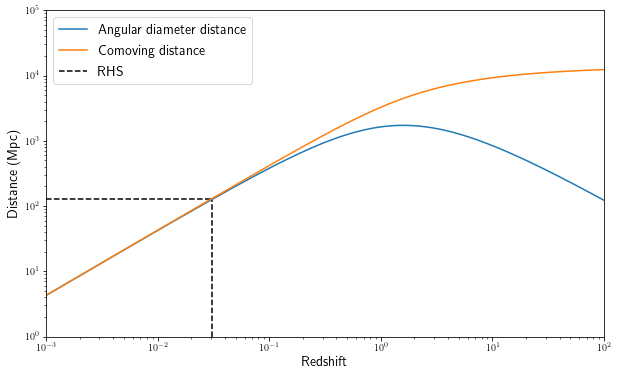

In [153]:
fs = 14
fig,ax = plt.subplots(figsize=(10,6))
ax.loglog(zs,res/(1+zs),label = r'Angular diameter distance')
ax.loglog(zs,res,label = r'Comoving distance')
ax.set_ylabel(r'Distance (Mpc)',fontsize = fs)
ax.set_xlabel(r'Redshift',fontsize = fs)
ax.hlines(RHS/1e6,1e-3,final_z,'k',ls = '--',label = r'RHS')
ax.vlines(final_z,1e0,RHS/1e6,'k',ls = '--')
ax.legend(fontsize = fs)
ax.set_xlim(0.001,100)
ax.set_ylim(1,1e5)

The brightness (net flux) from the Sun positioned at $d_C\sim$131 Mpc ($z = 0.0308$) is:

$$F = \frac{L_\odot}{4\pi d_L^2} = \frac{L_\odot}{4\pi d_C^2(1+z)^2} = \frac{4\cdot10^{33}{\rm erg\,s^{-1}}}{12 \cdot(131\cdot 10^6 \cdot 3\cdot10^{18} {\rm cm})^2\cdot 1.063} \doteq 1.7\cdot 10^{-22}\, {\rm erg\, cm^{-2}\, s^{-1}}$$

In [157]:
F = 4e33/(12*131*1e6*3*1e18)**2/1.063